# 双重差分 DiD · 快速演示 Notebook

> 配套技能：`67-econfin-workflow-toolkit/did-analysis`
> 配套幻灯片：`社科实证论文工作流.pptx`（第 17–21 页）

这个 Notebook 用一份**模拟数据**，把一个完整的 DiD 分析从头到尾跑通，对应工作流里的
**第④阶段（计量估计）**。整套流程分 6 步：

| 步 | 内容 | 对应技能动作 |
|---|---|---|
| ① | 生成模拟面板（植入已知真实 ATT） | 让你能对照『估计是否还原真值』 |
| ② | 可视化原始趋势 | 肉眼看处理后是否分叉 |
| ③ | 2×2 与 TWFE 基准回归 | 读出 DiD 系数 β₃，聚类稳健标准误 |
| ④ | 事件研究 + 平行趋势检验 | 生成可放进论文的 Figure |
| ⑤ | 稳健性：安慰剂检验 | 确认主效应不是噪声 |
| ⑥ | 导出回归表与事件研究图 | 进入第⑤阶段 table / figure |

**依赖**：`pandas` `numpy` `statsmodels` `matplotlib`（可选 `linearmodels`）。
全部 cell 从上到下运行即可，无需任何外部数据文件。

## 0 · 环境与全局设置

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

# 中文显示：只挑 matplotlib 字体管理器里**确实存在**的中文字体（找不到也不影响计算）
import matplotlib.font_manager as fm
_avail = {f.name for f in fm.fontManager.ttflist}
_prefer = ["PingFang SC", "Hiragino Sans GB", "Heiti SC", "STHeiti", "Songti SC",
           "Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC",
           "PingFang HK", "Arial Unicode MS"]
_chosen = next((f for f in _prefer if f in _avail), None)
if _chosen:
    matplotlib.rcParams["font.sans-serif"] = [_chosen] + matplotlib.rcParams["font.sans-serif"]
    print("图表中文字体:", _chosen)
else:
    print("未发现中文字体，图中中文可能显示为方块（不影响计算）。")
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 110

RNG = np.random.default_rng(20260618)   # 固定随机种子，结果可复现
ASSETS = Path("assets"); ASSETS.mkdir(exist_ok=True)

# 真实参数（我们自己设定，稍后看估计能否还原）
TRUE_ATT   = 2.0       # 真实处理效应（每期）
N_UNITS    = 200       # 个体数
YEARS      = list(range(2010, 2022))   # 12 年
TREAT_YEAR = 2016      # 处理组在这一年开始受政策影响（块状/共同时点设计）
print("设定的真实 ATT =", TRUE_ATT, "| 个体数 =", N_UNITS, "| 年份 =", YEARS[0], "-", YEARS[-1])

图表中文字体: Hiragino Sans GB
设定的真实 ATT = 2.0 | 个体数 = 200 | 年份 = 2010 - 2021


## ① 生成模拟面板数据

构造一个标准的 DiD 数据生成过程（DGP）：

$$Y_{it} = \alpha_i + \delta_t + \tau \cdot D_{it} + \varepsilon_{it}$$

- $\alpha_i$：个体固定效应（不随时间变）
- $\delta_t$：年份固定效应（所有个体共享的时间趋势）—— 这正是 DiD 要『差掉』的共同趋势
- $D_{it} = \text{Treat}_i \times \text{Post}_t$：处理组在 2016 年及以后取 1
- $\tau = $ `TRUE_ATT`：我们植入的真实处理效应

**关键**：处理组与对照组只在『水平』上不同，时间趋势 $\delta_t$ 对两组**相同** → 平行趋势成立。

In [2]:
# 个体固定效应：处理组基线略高（制造组间水平差，DiD 正是要消除它）
treat_flag = (np.arange(N_UNITS) < N_UNITS // 2).astype(int)   # 前一半为处理组
alpha_i = RNG.normal(0, 1.0, N_UNITS) + treat_flag * 1.5       # 处理组基线 +1.5

# 年份固定效应：一条所有个体共享的非线性时间趋势
year_index = {y: k for k, y in enumerate(YEARS)}
delta_t = {y: 0.4 * k + 0.6 * np.sin(k) for k, y in enumerate(YEARS)}

rows = []
for i in range(N_UNITS):
    for y in YEARS:
        post = int(y >= TREAT_YEAR)
        treat = int(treat_flag[i])
        d_it = treat * post                              # 处理指示
        eps = RNG.normal(0, 1.0)
        y_val = alpha_i[i] + delta_t[y] + TRUE_ATT * d_it + eps
        rows.append((i, y, treat, post, d_it, y_val))

df = pd.DataFrame(rows, columns=["unit", "year", "treat", "post", "treat_post", "y"])
df["rel_time"] = np.where(df["treat"] == 1, df["year"] - TREAT_YEAR, np.nan)  # 相对处理的时间
print(df.shape, "条观测 |", df["unit"].nunique(), "个体 ×", df["year"].nunique(), "年")
df.head(8)

(2400, 7) 条观测 | 200 个体 × 12 年


,unit,year,treat,post,treat_post,y,rel_time
0,0,2010,1,0,0,-0.235763,-6.0
1,0,2011,1,0,0,3.951752,-5.0
2,0,2012,1,0,0,1.861953,-4.0
3,0,2013,1,0,0,2.379561,-3.0
4,0,2014,1,0,0,2.467311,-2.0
5,0,2015,1,0,0,2.083525,-1.0
6,0,2016,1,1,1,5.497438,0.0
7,0,2017,1,1,1,6.798120,1.0


## ② 可视化原始趋势（识别的直觉）

DiD 的可信度，七成在这张图上：**处理前两组应当平行，处理后处理组才分叉。**

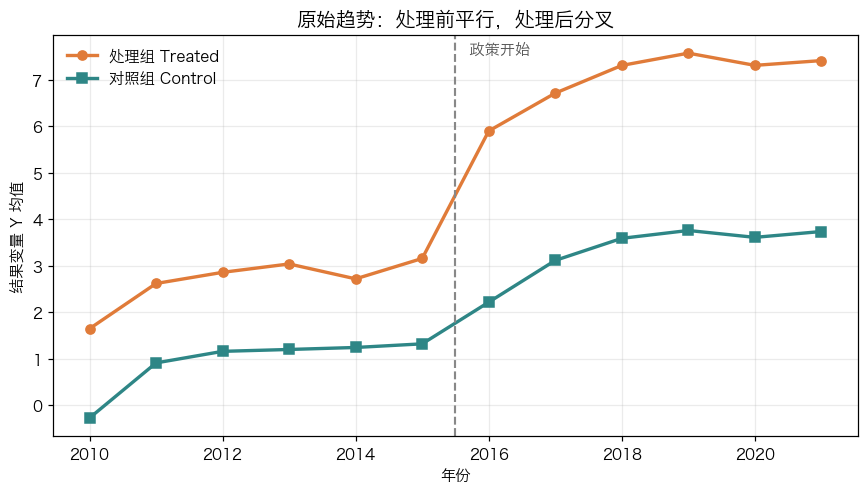

处理后两组均值差（含基线差，未净化）: 3.7


In [3]:
g = df.groupby(["year", "treat"])["y"].mean().unstack("treat")
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(g.index, g[1], marker="o", lw=2.2, color="#E07B39", label="处理组 Treated")
ax.plot(g.index, g[0], marker="s", lw=2.2, color="#2E8686", label="对照组 Control")
ax.axvline(TREAT_YEAR - 0.5, ls="--", color="#888", lw=1.4)
ax.text(TREAT_YEAR - 0.45, ax.get_ylim()[1]*0.98, "  政策开始", color="#555", va="top")
ax.set_xlabel("年份"); ax.set_ylabel("结果变量 Y 均值")
ax.set_title("原始趋势：处理前平行，处理后分叉", fontsize=13, weight="bold")
ax.legend(frameon=False); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(ASSETS / "fig_raw_trends.png", dpi=150, bbox_inches="tight")
plt.show()
print("处理后两组均值差（含基线差，未净化）:", round((g[1]-g[0]).loc[TREAT_YEAR:].mean(), 3))

## ③ 基准估计：手算 2×2 → OLS → 双向固定效应 TWFE

三种口径应当彼此印证，并落在真实 ATT = 2.0 附近。

In [4]:
# (a) 手算 2×2：四个均值，两次相减
m = df.groupby(["treat", "post"])["y"].mean()
did_2x2 = (m.loc[(1,1)] - m.loc[(1,0)]) - (m.loc[(0,1)] - m.loc[(0,0)])
print("【2×2 手算】")
print("  处理组  Δ =", round(m.loc[(1,1)] - m.loc[(1,0)], 3))
print("  对照组  Δ =", round(m.loc[(0,1)] - m.loc[(0,0)], 3))
print("  DiD = Δ_T − Δ_C =", round(did_2x2, 3), "  (真实 ATT =", TRUE_ATT, ")")

【2×2 手算】
  处理组  Δ = 4.366
  对照组  Δ = 2.413
  DiD = Δ_T − Δ_C = 1.953   (真实 ATT = 2.0 )


In [5]:
# (b) 简单 OLS：y ~ treat + post + treat_post，个体层聚类稳健标准误
ols = smf.ols("y ~ treat + post + treat_post", data=df).fit(
    cov_type="cluster", cov_kwds={"groups": df["unit"]})
print(ols.summary().tables[1])
print("\n→ treat_post 系数 = DiD 估计 (ATT):", round(ols.params["treat_post"], 3))

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9276      0.104      8.895      0.000       0.723       1.132
treat          1.7477      0.160     10.922      0.000       1.434       2.061
post           2.4132      0.059     41.213      0.000       2.298       2.528
treat_post     1.9526      0.083     23.562      0.000       1.790       2.115

→ treat_post 系数 = DiD 估计 (ATT): 1.953


In [6]:
# (c) 双向固定效应 TWFE：个体 FE + 年份 FE（吸收 alpha_i 与 delta_t），按个体聚类
twfe = smf.ols("y ~ treat_post + C(unit) + C(year)", data=df).fit(
    cov_type="cluster", cov_kwds={"groups": df["unit"]})
b   = twfe.params["treat_post"]
se  = twfe.bse["treat_post"]
ci  = twfe.conf_int().loc["treat_post"].values
print("【TWFE】 ATT = {:.3f}   SE = {:.3f}   95% CI = [{:.3f}, {:.3f}]   p = {:.3g}".format(
    b, se, ci[0], ci[1], twfe.pvalues["treat_post"]))
print("真实 ATT =", TRUE_ATT, "→ 成功还原 ✅" if abs(b - TRUE_ATT) < 3*se else "→ 偏离，需排查")

# 可选：用 linearmodels 的 PanelOLS 复核（若已安装）
try:
    from linearmodels.panel import PanelOLS
    pdf = df.set_index(["unit", "year"])
    res = PanelOLS(pdf["y"], pdf[["treat_post"]],
                   entity_effects=True, time_effects=True).fit(
                   cov_type="clustered", cluster_entity=True)
    print("linearmodels PanelOLS 复核 ATT =", round(float(res.params["treat_post"]), 3))
except Exception as e:
    print("(linearmodels 未安装，跳过复核：statsmodels 结果已足够)")

【TWFE】 ATT = 1.953   SE = 0.087   95% CI = [1.783, 2.123]   p = 2.87e-112
真实 ATT = 2.0 → 成功还原 ✅


linearmodels PanelOLS 复核 ATT = 1.953


## ④ 事件研究 + 平行趋势检验

把单一的 `treat_post` 拆成**相对时间**虚拟变量（以 $t=-1$ 为基准），
处理前的系数应当贴近 0（平行趋势），处理后给出动态效应。这张图是 DiD 论文的『门面图』。

In [7]:
# 为处理组构造相对时间哑变量；对照组 rel_time 为 NaN（自动落入基准）
es_df = df.copy()
es_df["rt"] = es_df["rel_time"]
# 把端点截断以避免稀疏：相对时间限定在 [-6, 5]
es_df["rt"] = es_df["rt"].clip(-6, 5)

# 相对时间 k → 合法的列名（避免公式里的 '-' 被当成减号）
def rtname(k):
    return f"d_n{-k}" if k < 0 else f"d_p{k}"

# 以 rel_time = -1 为参照组：构造除 -1 外每个相对期的交互哑变量
rel_periods = [k for k in range(-6, 6) if k != -1]
for k in rel_periods:
    es_df[rtname(k)] = ((es_df["treat"] == 1) & (es_df["rt"] == k)).astype(int)

terms = " + ".join([rtname(k) for k in rel_periods])
es = smf.ols(f"y ~ {terms} + C(unit) + C(year)", data=es_df).fit(
    cov_type="cluster", cov_kwds={"groups": es_df["unit"]})

# 收集系数与置信区间
coefs, los, his = [], [], []
for k in range(-6, 6):
    if k == -1:
        coefs.append(0.0); los.append(0.0); his.append(0.0)
    else:
        coefs.append(es.params[rtname(k)])
        lo, hi = es.conf_int().loc[rtname(k)].values
        los.append(lo); his.append(hi)
xs = list(range(-6, 6))

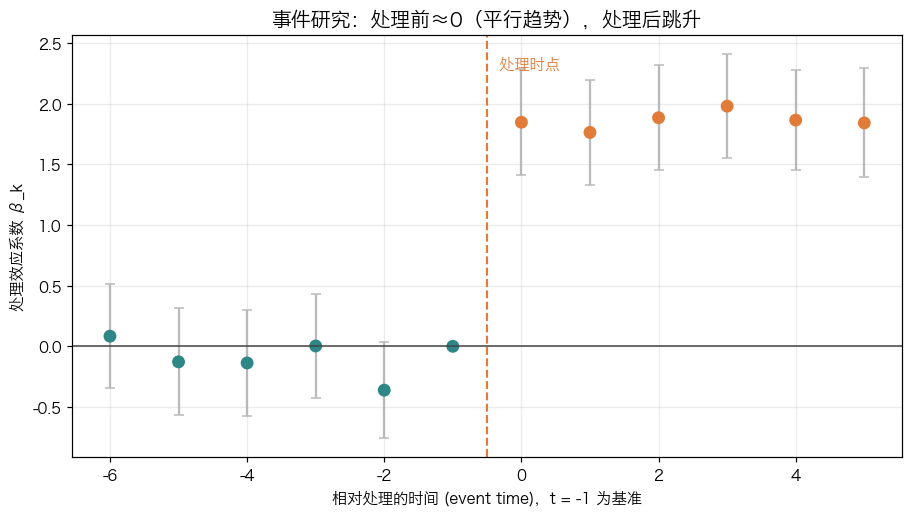

In [8]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
pre  = [x < 0 for x in xs]
colors = ["#2E8686" if p else "#E07B39" for p in pre]
ax.errorbar(xs, coefs, yerr=[np.array(coefs)-np.array(los), np.array(his)-np.array(coefs)],
            fmt="none", ecolor="#bbb", capsize=3, zorder=1)
ax.scatter(xs, coefs, c=colors, s=55, zorder=2)
ax.axhline(0, color="#444", lw=1)
ax.axvline(-0.5, ls="--", color="#E07B39", lw=1.4)
ax.text(-0.4, max(his)*0.95, " 处理时点", color="#E07B39")
ax.set_xlabel("相对处理的时间 (event time)，t = -1 为基准")
ax.set_ylabel("处理效应系数 β_k")
ax.set_title("事件研究：处理前≈0（平行趋势），处理后跳升", fontsize=13, weight="bold")
ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(ASSETS / "fig_event_study.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# 平行趋势的正式检验：处理前所有系数联合 = 0 的 Wald F 检验
pre_terms = [rtname(k) for k in range(-6, 0) if k != -1]
hypotheses = ", ".join([f"{t} = 0" for t in pre_terms])
ftest = es.f_test(hypotheses)
print("处理前联合检验  H0: 所有 pre 系数 = 0")
print("  F = {:.3f},  p = {:.3f}".format(float(ftest.fvalue), float(ftest.pvalue)))
print("  →", "不能拒绝 H0，平行趋势获得支持 ✅" if float(ftest.pvalue) > 0.10
      else "拒绝 H0，存在预趋势，需谨慎 ⚠️")
print("\n注意：不拒绝 ≠ 平行趋势必然成立（可能只是检验功效低）。")
print("严谨做法可进一步做 Roth(2022) 预趋势功效分析与 honest-DiD 敏感性。")

处理前联合检验  H0: 所有 pre 系数 = 0
  F = 1.227,  p = 0.298
  → 不能拒绝 H0，平行趋势获得支持 ✅

注意：不拒绝 ≠ 平行趋势必然成立（可能只是检验功效低）。
严谨做法可进一步做 Roth(2022) 预趋势功效分析与 honest-DiD 敏感性。


## ⑤ 稳健性：安慰剂检验

两类经典安慰剂 —— 若主效应是真的，这两个『假效应』都应当**不显著**：

1. **伪处理时点**：只用处理前的样本，假装政策提前到 2013 年发生。
2. **伪处理组**：丢掉真处理组，只在对照单元里随机指定一个『假处理组』。

In [10]:
# (1) 伪处理时点：只取 2010-2015（真政策前），假装 2013 年开始
pre_only = df[df["year"] < TREAT_YEAR].copy()
pre_only["fake_post"] = (pre_only["year"] >= 2013).astype(int)
pre_only["fake_tp"]   = pre_only["treat"] * pre_only["fake_post"]
plc1 = smf.ols("y ~ treat_post + C(unit) + C(year)",
               data=pre_only.assign(treat_post=pre_only["fake_tp"])).fit(
               cov_type="cluster", cov_kwds={"groups": pre_only["unit"]})
print("【安慰剂①·伪处理时点 2013】 系数 = {:.3f}, p = {:.3f}  → {}".format(
    plc1.params["treat_post"], plc1.pvalues["treat_post"],
    "不显著，通过 ✅" if plc1.pvalues["treat_post"] > 0.10 else "显著，警惕 ⚠️"))

# (2) 伪处理组：仅用对照单元，随机指定一半为假处理组
ctrl = df[df["treat"] == 0].copy()
fake_units = RNG.choice(ctrl["unit"].unique(),
                        size=ctrl["unit"].nunique() // 2, replace=False)
ctrl["fake_treat"] = ctrl["unit"].isin(fake_units).astype(int)
ctrl["fake_tp"]    = ctrl["fake_treat"] * ctrl["post"]
plc2 = smf.ols("y ~ fake_treat + post + fake_tp + C(unit) + C(year)",
               data=ctrl).fit(cov_type="cluster", cov_kwds={"groups": ctrl["unit"]})
print("【安慰剂②·伪处理组】     系数 = {:.3f}, p = {:.3f}  → {}".format(
    plc2.params["fake_tp"], plc2.pvalues["fake_tp"],
    "不显著，通过 ✅" if plc2.pvalues["fake_tp"] > 0.10 else "显著，警惕 ⚠️"))

【安慰剂①·伪处理时点 2013】 系数 = -0.059, p = 0.641  → 不显著，通过 ✅
【安慰剂②·伪处理组】     系数 = -0.092, p = 0.454  → 不显著，通过 ✅


## ⑥ 导出回归表与图（进入第⑤阶段 table / figure）

把主回归整理成一张『出版级』迷你表（文本 + LaTeX），并确认图已落盘。

In [11]:
def stars(p):
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""

specs = [("(1) OLS", ols, "treat_post"),
         ("(2) TWFE", twfe, "treat_post")]
print("=" * 46)
print("{:<16}{:>14}{:>16}".format("", "(1) OLS", "(2) TWFE"))
print("-" * 46)
b1, b2 = ols.params["treat_post"], twfe.params["treat_post"]
s1, s2 = ols.bse["treat_post"],   twfe.bse["treat_post"]
print("{:<16}{:>14}{:>16}".format("Treat×Post",
      f"{b1:.3f}{stars(ols.pvalues['treat_post'])}",
      f"{b2:.3f}{stars(twfe.pvalues['treat_post'])}"))
print("{:<16}{:>14}{:>16}".format("", f"({s1:.3f})", f"({s2:.3f})"))
print("{:<16}{:>14}{:>16}".format("个体固定效应", "No", "Yes"))
print("{:<16}{:>14}{:>16}".format("年份固定效应", "No", "Yes"))
print("{:<16}{:>14}{:>16}".format("N", f"{int(ols.nobs)}", f"{int(twfe.nobs)}"))
print("=" * 46)
print("括号内为个体层聚类稳健标准误。*** p<0.01, ** p<0.05, * p<0.10")

latex = r'''\begin{tabular}{lcc}
\hline\hline
 & (1) OLS & (2) TWFE \\
\hline
Treat$\times$Post & %.3f%s & %.3f%s \\
 & (%.3f) & (%.3f) \\
个体固定效应 & No & Yes \\
年份固定效应 & No & Yes \\
$N$ & %d & %d \\
\hline\hline
\end{tabular}''' % (b1, stars(ols.pvalues['treat_post']), b2, stars(twfe.pvalues['treat_post']),
                    s1, s2, int(ols.nobs), int(twfe.nobs))
Path("assets/did_table.tex").write_text(latex, encoding="utf-8")
print("\n已导出：")
for f in ["assets/fig_raw_trends.png", "assets/fig_event_study.png", "assets/did_table.tex"]:
    print("  •", f)

                       (1) OLS        (2) TWFE
----------------------------------------------
Treat×Post            1.953***        1.953***
                       (0.083)         (0.087)
个体固定效应                      No             Yes
年份固定效应                      No             Yes
N                         2400            2400
括号内为个体层聚类稳健标准误。*** p<0.01, ** p<0.05, * p<0.10

已导出：
  • assets/fig_raw_trends.png
  • assets/fig_event_study.png
  • assets/did_table.tex


## ⑦ 附：交错处理时为什么不能无脑 TWFE

上面是『共同时点』块状设计，TWFE 无偏。但当各单位在**不同时间**被处理、且**效应随时间增长**（异质动态）时，
标准 TWFE 会用『已处理单位』当对照、产生负权重，估计可能严重有偏。下面用一个小模拟戳穿它。

In [12]:
# 交错采纳 + 动态增长效应：cohort 在 2013/2016/2019 三批进入，效应逐期累积
cohorts = {0: None, 1: 2013, 2: 2016, 3: 2019}   # 4 组，1 组永不处理
rows = []
true_effects = []
for i in range(N_UNITS):
    g = i % 4                          # 平均分到 4 组
    gyear = cohorts[g]
    ai = RNG.normal(0, 1.0)
    for y in YEARS:
        dt = 0.4 * year_index[y]
        if gyear is None or y < gyear:
            eff = 0.0
        else:
            eff = 0.6 * (y - gyear + 1)   # 处理后效应逐期变大（异质动态）
        if eff > 0:
            true_effects.append(eff)
        d_it = int(gyear is not None and y >= gyear)
        rows.append((i, y, d_it, ai + dt + eff + RNG.normal(0, 1.0)))
sdf = pd.DataFrame(rows, columns=["unit", "year", "d_it", "y"])

twfe_stag = smf.ols("y ~ d_it + C(unit) + C(year)", data=sdf).fit(
    cov_type="cluster", cov_kwds={"groups": sdf["unit"]})
true_avg = np.mean(true_effects)
print("交错 + 动态效应设计：")
print("  真实平均处理效应 (ATT)      = {:.3f}".format(true_avg))
print("  朴素 TWFE 估计              = {:.3f}".format(twfe_stag.params["d_it"]))
print("  偏差                       = {:.3f}".format(twfe_stag.params["d_it"] - true_avg))
print("\n→ TWFE 明显偏离真值。实务中应改用现代估计量：")
print("   Callaway & Sant'Anna (csdid/did)、Sun & Abraham (sunab)、")
print("   Borusyak et al. (did_imputation)、de Chaisemartin–D'Haultfœuille。")
print("   先用 Goodman-Bacon 分解诊断『坏对照』权重，再决定换哪一个。")

交错 + 动态效应设计：
  真实平均处理效应 (ATT)      = 2.400
  朴素 TWFE 估计              = 1.305
  偏差                       = -1.095

→ TWFE 明显偏离真值。实务中应改用现代估计量：
   Callaway & Sant'Anna (csdid/did)、Sun & Abraham (sunab)、
   Borusyak et al. (did_imputation)、de Chaisemartin–D'Haultfœuille。
   先用 Goodman-Bacon 分解诊断『坏对照』权重，再决定换哪一个。


## 小结

- **③** 三种口径（2×2 / OLS / TWFE）一致还原了植入的真实 ATT = 2.0 → 估计可信。
- **④** 事件研究处理前系数贴近 0、联合检验不拒绝 → 平行趋势获得支持；处理后系数给出动态效应。
- **⑤** 两个安慰剂都不显著 → 主效应稳健。
- **⑦** 一旦处理时点交错且效应异质，朴素 TWFE 有偏 → 换 CS / SA / BJS。

**下一步（回到工作流）**：把 `assets/` 里的表与图接入第⑤阶段的 `table` / `figure` 技能整理成出版级版式，
再进入第⑥阶段 `paper-writer` / `paper-pipeline` 写作打磨。

> 想换成你自己的数据？把第 ① 步替换为 `df = pd.read_csv("your_panel.csv")`，
> 并保证含有 `unit, year, treat, post, treat_post, y` 这几列即可，后续 cell 无需改动。